# Lab 6: Spinning and Rolling Objects

**Name:** Alex Bebb  
**Course:** PHYS 311  
**Date:** October 4, 2026  

In this lab, I will model a physical pendulum, compare objects rolling
down an incline, and investigate how changing a skater's moment of
inertia affects their rotation. I will check the results against
theoretical predictions and the conservation laws that apply to each
system.

For the bonus, I will combine rolling motion with a collision.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Gravitational acceleration; use SI units throughout.
g = 9.81  # m/s^2

## Warm-up: Moment of inertia

Moment of inertia describes how strongly an object resists changes in
its rotational motion. It depends on both the masses and their distances
from the rotation axis:

$$
I = \sum_i m_i r_i^2.
$$

I will calculate the moment of inertia of four equal point masses at
the corners of a square. The rotation axes will be perpendicular to
the square, passing through either its center or one corner.

I will then check the results using the parallel-axis theorem:

$$
I_{\mathrm{corner}} = I_{\mathrm{center}} + M d^2,
$$

where $M$ is the total mass and $d$ is the distance between the axes.
The masses will be treated as point particles, with any connecting
structure assumed to have negligible mass.

In [2]:
def moment_of_inertia(masses, positions, axis):
    """Calculate the moment of inertia about an axis perpendicular to the plane."""
    I = 0.0

    for mass, position in zip(masses, positions):
        displacement = np.asarray(position) - np.asarray(axis)
        distance_squared = np.sum(displacement**2)
        I += mass * distance_squared

    return I


# Four 1 kg point masses at the corners of a square with 2 m sides.
masses = np.array([1.0, 1.0, 1.0, 1.0])

positions = np.array([
    [-1.0, -1.0],
    [ 1.0, -1.0],
    [ 1.0,  1.0],
    [-1.0,  1.0]
])

center_axis = np.array([0.0, 0.0])
corner_axis = positions[0]

I_center = moment_of_inertia(masses, positions, center_axis)
I_corner = moment_of_inertia(masses, positions, corner_axis)

# Independently predict the corner value using the parallel-axis theorem.
total_mass = np.sum(masses)
axis_distance_squared = np.sum((corner_axis - center_axis)**2)
I_corner_predicted = I_center + total_mass * axis_distance_squared

print(f"Total mass: {total_mass:.2f} kg")
print(f"Moment of inertia about center: {I_center:.2f} kg m^2")
print(f"Moment of inertia about corner: {I_corner:.2f} kg m^2")
print(f"Parallel-axis prediction: {I_corner_predicted:.2f} kg m^2")
print(f"Results agree: {np.isclose(I_corner, I_corner_predicted)}")

Total mass: 4.00 kg
Moment of inertia about center: 8.00 kg m^2
Moment of inertia about corner: 16.00 kg m^2
Parallel-axis prediction: 16.00 kg m^2
Results agree: True


### Interpretation

The moment of inertia was 8 kg m² about the center and 16 kg m²
about a corner. The corner result agreed with the parallel-axis
theorem.

Moving the axis changed the distances of the masses from the axis,
even though the masses and their arrangement stayed the same.
The larger moment of inertia about the corner means that the same
net torque would produce a smaller angular acceleration about that
axis.

## Part A: Physical pendulum

I will model a uniform rod swinging about a fixed pivot at one end.
The model will neglect air resistance and friction at the pivot.

The rod's center of mass is a distance $d=L/2$ from the pivot, and
its moment of inertia about the pivot is

$$
I = \frac{1}{3}mL^2.
$$

I will measure the angle $\theta$ from the vertically downward
equilibrium position. Gravity produces a restoring torque:

$$
\tau = -mgd\sin(\theta).
$$

Because the moment of inertia is constant, the angular acceleration is

$$
\alpha = \frac{\tau}{I}.
$$

I will use the rotational version of Euler-Cromer. Each step will
update the angular velocity first, then use that new angular velocity
to update the angle:

$$
\omega_{n+1} = \omega_n + \frac{\tau_n}{I}\Delta t,
$$

$$
\theta_{n+1} = \theta_n + \omega_{n+1}\Delta t.
$$

In [3]:
def rotate_step(theta, omega, torque, I, dt):
    """Advance angle and angular velocity by one Euler-Cromer step."""
    alpha = torque / I
    omega = omega + alpha * dt
    theta = theta + omega * dt

    return theta, omega

### Parameters and small-angle prediction

I will use a rod with a mass of 1 kg and a length of 1 m.

For small angles measured in radians, $\sin(\theta)\approx\theta$.
With this approximation, the rod behaves like a simple harmonic
oscillator with natural angular frequency

$$
\Omega = \sqrt{\frac{mgd}{I}}
       = \sqrt{\frac{3g}{2L}}.
$$

Its predicted small-angle period is

$$
T_0 = \frac{2\pi}{\Omega}.
$$

For release from rest, the small-angle prediction for the motion is

$$
\theta_{\mathrm{small}}(t) = \theta_0\cos(\Omega t).
$$

I will first use an initial angle of 0.3 radians and compare the
numerical solution with this prediction. The numerical model will
retain the full sine function in the torque.

In [4]:
# Physical parameters of the rod.
m_rod = 1.0  # kg
L_rod = 1.0  # m
d_rod = L_rod / 2
I_rod = (1 / 3) * m_rod * L_rod**2  # kg m^2

# Small-angle theoretical predictions.
Omega_rod = np.sqrt(m_rod * g * d_rod / I_rod)
T_small = 2 * np.pi / Omega_rod

# Initial conditions and simulation settings.
theta0_small = 0.3  # rad
omega0 = 0.0        # rad/s
dt_pendulum = 0.001  # s
duration_pendulum = 10.0  # s

print(f"Rod mass: {m_rod:.2f} kg")
print(f"Rod length: {L_rod:.2f} m")
print(f"Pivot-to-center-of-mass distance: {d_rod:.2f} m")
print(f"Moment of inertia: {I_rod:.6f} kg m^2")
print(f"Small-angle angular frequency: {Omega_rod:.6f} rad/s")
print(f"Small-angle period: {T_small:.6f} s")
print(f"Initial angle: {theta0_small:.3f} rad "
      f"({np.degrees(theta0_small):.2f} degrees)")

Rod mass: 1.00 kg
Rod length: 1.00 m
Pivot-to-center-of-mass distance: 0.50 m
Moment of inertia: 0.333333 kg m^2
Small-angle angular frequency: 3.836014 rad/s
Small-angle period: 1.637947 s
Initial angle: 0.300 rad (17.19 degrees)


### Simulating the physical pendulum

I will write a function that stores the angle and angular velocity
throughout the simulation. At each time step, it will calculate the
gravitational torque using the current angle, then call the
Euler-Cromer update function.

The torque will use the full expression $-mgd\sin(\theta)$, so the
same simulation function can handle both small and large angles.

The function will return arrays containing the times, angles, and
angular velocities for plotting and analysis.

In [5]:
def simulate_rod(theta_initial, omega_initial, dt, duration):
    """Simulate the uniform rod using rotational Euler-Cromer."""
    n_steps = int(np.ceil(duration / dt))

    times = np.arange(n_steps + 1) * dt
    angles = np.zeros(n_steps + 1)
    angular_velocities = np.zeros(n_steps + 1)

    # Store the initial conditions.
    angles[0] = theta_initial
    angular_velocities[0] = omega_initial

    for i in range(n_steps):
        torque = -m_rod * g * d_rod * np.sin(angles[i])

        angles[i + 1], angular_velocities[i + 1] = rotate_step(
            theta=angles[i],
            omega=angular_velocities[i],
            torque=torque,
            I=I_rod,
            dt=dt
        )

    return times, angles, angular_velocities

### Small-angle comparison

I will release the rod from rest at 0.3 radians and simulate its motion
for 10 seconds. I will overlay the numerical result with the
small-angle prediction:

$$
\theta_{\mathrm{small}}(t) = \theta_0\cos(\Omega t).
$$

The curves should be close, although the small-angle approximation
is not exact at a finite release angle. A slight difference in period
can produce an increasing phase difference over several oscillations.

Simulation duration: 10.000 s
Stored time points: 10001
Initial angle: 0.300 rad
Initial angular velocity: 0.000 rad/s


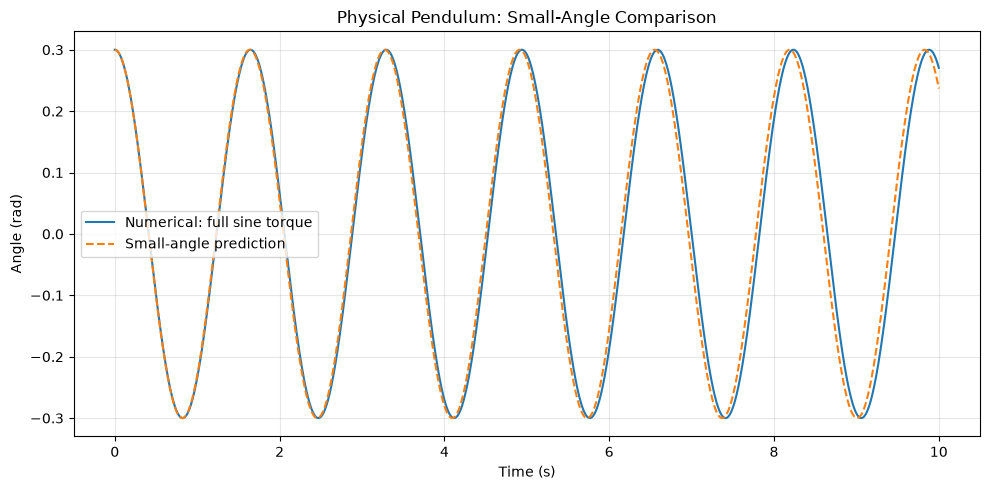

In [6]:
# Run the numerical simulation.
t_small, theta_small, omega_small = simulate_rod(
    theta_initial=theta0_small,
    omega_initial=omega0,
    dt=dt_pendulum,
    duration=duration_pendulum
)

# Evaluate the small-angle prediction at the same times.
theta_prediction_small = theta0_small * np.cos(Omega_rod * t_small)

print(f"Simulation duration: {t_small[-1]:.3f} s")
print(f"Stored time points: {len(t_small)}")
print(f"Initial angle: {theta_small[0]:.3f} rad")
print(f"Initial angular velocity: {omega_small[0]:.3f} rad/s")

plt.figure(figsize=(10, 5))

plt.plot(
    t_small, theta_small,
    label="Numerical: full sine torque"
)
plt.plot(
    t_small, theta_prediction_small,
    linestyle="--",
    label="Small-angle prediction"
)

plt.xlabel("Time (s)")
plt.ylabel("Angle (rad)")
plt.title("Physical Pendulum: Small-Angle Comparison")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Large-angle comparison

I will repeat the simulation with an initial angle of 2.5 radians,
again releasing the rod from rest. This is approximately 143 degrees
from the vertically downward equilibrium position.

At this angle, the approximation $\sin(\theta)\approx\theta$ is no
longer accurate. I will compare the full-sine numerical solution with
the small-angle formula using the same initial angle.

I expect the numerical pendulum to have a noticeably longer period.
The small-angle model overestimates the magnitude of the restoring
torque at large displacements, so it predicts a faster return toward
equilibrium.

Initial angle: 2.500 rad (143.24 degrees)
Initial angular velocity: 0.000 rad/s
Small-angle predicted period: 1.637947 s


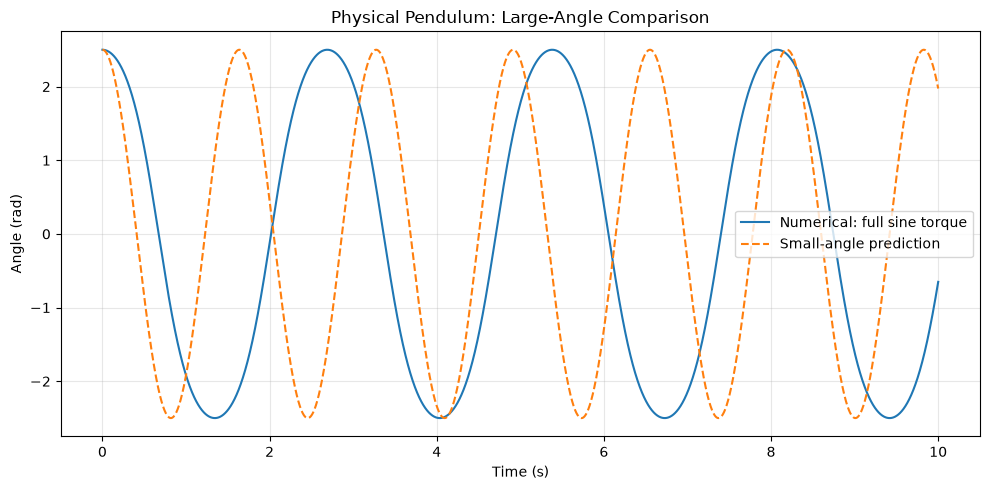

In [7]:
# Release the rod from rest at a large angle.
theta0_large = 2.5  # rad

t_large, theta_large, omega_large = simulate_rod(
    theta_initial=theta0_large,
    omega_initial=omega0,
    dt=dt_pendulum,
    duration=duration_pendulum
)

# Apply the small-angle formula for comparison.
theta_prediction_large = theta0_large * np.cos(Omega_rod * t_large)

print(f"Initial angle: {theta0_large:.3f} rad "
      f"({np.degrees(theta0_large):.2f} degrees)")
print(f"Initial angular velocity: {omega_large[0]:.3f} rad/s")
print(f"Small-angle predicted period: {T_small:.6f} s")

plt.figure(figsize=(10, 5))

plt.plot(
    t_large, theta_large,
    label="Numerical: full sine torque"
)
plt.plot(
    t_large, theta_prediction_large,
    linestyle="--",
    label="Small-angle prediction"
)

plt.xlabel("Time (s)")
plt.ylabel("Angle (rad)")
plt.title("Physical Pendulum: Large-Angle Comparison")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Period measurement and time-step refinement

I will measure the period by recording when the rod passes through
equilibrium in the negative direction. Successive crossings in the
same direction are one full oscillation apart.

Because a crossing will usually occur between stored times, I will
estimate its time by linear interpolation between the two surrounding
points. I will then average the intervals between successive crossings.

I will repeat both simulations with half the original time step.
If the measured periods change very little, this will support the
conclusion that the longer large-angle period is a physical effect
rather than mainly a time-step error. This check tests the period,
rather than every aspect of the simulated trajectory.

In [8]:
def measure_period(times, angles):
    """Average the intervals between downward equilibrium crossings."""
    crossing_times = []

    for i in range(len(angles) - 1):
        # Detect a crossing from positive angle to zero or negative angle.
        if angles[i] > 0 and angles[i + 1] <= 0:
            fraction = angles[i] / (angles[i] - angles[i + 1])

            crossing_time = (
                times[i] + fraction * (times[i + 1] - times[i])
            )
            crossing_times.append(crossing_time)

    if len(crossing_times) < 2:
        raise ValueError("Run the simulation longer to measure a full period.")

    return np.mean(np.diff(crossing_times))


# Measure periods from the simulations already completed.
period_small = measure_period(t_small, theta_small)
period_large = measure_period(t_large, theta_large)

# Repeat both simulations with half the time step.
dt_refined = dt_pendulum / 2

t_small_refined, theta_small_refined, omega_small_refined = simulate_rod(
    theta_initial=theta0_small,
    omega_initial=omega0,
    dt=dt_refined,
    duration=duration_pendulum
)

t_large_refined, theta_large_refined, omega_large_refined = simulate_rod(
    theta_initial=theta0_large,
    omega_initial=omega0,
    dt=dt_refined,
    duration=duration_pendulum
)

period_small_refined = measure_period(t_small_refined, theta_small_refined)
period_large_refined = measure_period(t_large_refined, theta_large_refined)

print(f"Small-angle theoretical period: {T_small:.6f} s")
print(f"Original time step: {dt_pendulum:.6f} s")
print(f"Refined time step: {dt_refined:.6f} s")

print(
    f"\n{'Initial angle':>15} {'Original T (s)':>16}"
    f" {'Refined T (s)':>16} {'Change (%)':>14}"
)

for angle, original, refined in [
    (theta0_small, period_small, period_small_refined),
    (theta0_large, period_large, period_large_refined)
]:
    change_percent = 100 * abs(refined - original) / abs(refined)

    print(
        f"{angle:>11.3f} rad {original:>16.8f}"
        f" {refined:>16.8f} {change_percent:>14.6f}"
    )

print("\nPeriod increase relative to the small-angle prediction:")

for angle, period in [
    (theta0_small, period_small_refined),
    (theta0_large, period_large_refined)
]:
    increase_percent = 100 * (period - T_small) / T_small
    print(f"At {angle:.3f} rad: {increase_percent:.3f}%")

Small-angle theoretical period: 1.637947 s
Original time step: 0.001000 s
Refined time step: 0.000500 s

  Initial angle   Original T (s)    Refined T (s)     Change (%)
      0.300 rad       1.64720686       1.64720758       0.000044
      2.500 rad       2.69111873       2.69111774       0.000037

Period increase relative to the small-angle prediction:
At 0.300 rad: 0.565%
At 2.500 rad: 64.298%


### Part A interpretation

The small-angle simulation closely followed the analytical prediction,
although its slightly longer period caused the curves to gradually
separate. At an initial angle of 2.5 radians, the numerical period was
much longer and the motion differed noticeably from a sinusoid.

Halving the time step produced very little change in the measured
periods. This supported the conclusion that the large difference from
the small-angle prediction came from the nonlinear restoring torque,
rather than mainly from the numerical time step.

This was similar to the simple pendulum in Lab 3: increasing the
release angle increased the period. The physical pendulum used the
rod's moment of inertia and the position of its center of mass,
instead of treating all its mass as a point at the end of a string.

## Part B: Rolling race

I will compare a hoop, a solid disk, and a solid sphere rolling down
the same incline from rest. I will assume that each object rolls
without slipping and that air resistance and rolling resistance
are negligible.

Each object's moment of inertia about its center can be written as

$$
I = cmR^2,
$$

where the shape determines the coefficient:

- Hoop: $c=1$
- Solid disk: $c=1/2$
- Solid sphere: $c=2/5$

Taking downhill as positive, the translational equation is

$$
mg\sin(\beta)-f_s=ma.
$$

Static friction provides the torque needed for rotation. Using
$a=\alpha R$ for rolling without slipping gives

$$
f_sR=I\alpha
\quad\Rightarrow\quad
f_s=cma.
$$

Combining these equations gives

$$
a=\frac{g\sin(\beta)}{1+c}.
$$

I will assume there is enough static friction to maintain rolling
without slipping. The sphere should accelerate fastest, followed
by the disk and then the hoop.

In [9]:
def rolling_accel(beta, c, g=9.81):
    """Return downhill acceleration for ideal rolling without slipping."""
    return g * np.sin(beta) / (1 + c)

### Race parameters and theoretical predictions

I will use a 2 m ramp inclined at 20 degrees. Each object will have
a mass of 1 kg and a radius of 0.1 m, with distance measured downhill
from its starting position.

For constant acceleration from rest,

$$
s(t)=\frac{1}{2}at^2.
$$

The predicted time to travel the ramp distance $s_{\mathrm{end}}$ is

$$
t_{\mathrm{finish}}=\sqrt{\frac{2s_{\mathrm{end}}}{a}}.
$$

I will calculate each object's moment of inertia, acceleration, and
predicted finishing time before simulating the race. These predictions
will provide a check on the numerical results.

In [10]:
# Ramp and object parameters.
beta = np.radians(20.0)  # incline angle in radians
ramp_length = 2.0       # m
mass_rolling = 1.0      # kg
radius_rolling = 0.1    # m
dt_rolling = 0.001      # s

# Dictionary pairing each object name with its shape coefficient.
rolling_shapes = {
    "Hoop": 1.0,
    "Solid disk": 0.5,
    "Solid sphere": 2 / 5
}

print(f"Ramp length: {ramp_length:.2f} m")
print(f"Incline angle: {np.degrees(beta):.1f} degrees")
print(f"Object mass: {mass_rolling:.2f} kg")
print(f"Object radius: {radius_rolling:.2f} m")

print(
    f"\n{'Object':<15} {'c':>6} {'I (kg m^2)':>14}"
    f" {'a (m/s^2)':>13} {'Predicted t (s)':>17}"
)

for name, c in rolling_shapes.items():
    I_object = c * mass_rolling * radius_rolling**2
    acceleration = rolling_accel(beta, c, g)
    predicted_time = np.sqrt(2 * ramp_length / acceleration)

    print(
        f"{name:<15} {c:>6.2f} {I_object:>14.6f}"
        f" {acceleration:>13.6f} {predicted_time:>17.6f}"
    )

Ramp length: 2.00 m
Incline angle: 20.0 degrees
Object mass: 1.00 kg
Object radius: 0.10 m

Object               c     I (kg m^2)     a (m/s^2)   Predicted t (s)
Hoop              1.00       0.010000      1.677609          1.544133
Solid disk        0.50       0.005000      2.236812          1.337258
Solid sphere      0.40       0.004000      2.396584          1.291914


### Simulating motion down the ramp

I will advance each object's position and velocity until it reaches
the bottom of the ramp. Because the acceleration is constant, I can
use the constant-acceleration update equations:

$$
s_{n+1}=s_n+v_n\Delta t+\frac{1}{2}a(\Delta t)^2,
$$

$$
v_{n+1}=v_n+a\Delta t.
$$

These updates are exact for this ideal model, apart from floating-point
rounding. Rolling without slipping gives the angular velocity:

$$
\omega=\frac{v}{R}.
$$

If a full time step would carry an object beyond the ramp, I will
shorten the final step so its trajectory ends at the bottom.

In [11]:
def simulate_rolling(c, beta, ramp_length, radius, dt):
    """Simulate constant-acceleration rolling from rest."""
    acceleration = rolling_accel(beta, c, g)

    times = [0.0]
    positions = [0.0]
    velocities = [0.0]

    while positions[-1] < ramp_length:
        position = positions[-1]
        velocity = velocities[-1]
        remaining_distance = ramp_length - position

        # Time required to cover the remaining distance.
        time_to_finish = (
            2 * remaining_distance
            / (
                velocity
                + np.sqrt(
                    velocity**2 + 2 * acceleration * remaining_distance
                )
            )
        )

        step = min(dt, time_to_finish)

        new_position = (
            position + velocity * step + 0.5 * acceleration * step**2
        )
        new_velocity = velocity + acceleration * step

        # End exactly at the ramp's bottom on the final step.
        finished = time_to_finish <= dt
        if finished:
            new_position = ramp_length

        times.append(times[-1] + step)
        positions.append(new_position)
        velocities.append(new_velocity)

        if finished:
            break

    times = np.array(times)
    positions = np.array(positions)
    velocities = np.array(velocities)
    angular_velocities = velocities / radius

    return times, positions, velocities, angular_velocities

### Comparing the trajectories and finishing times

I will run the rolling simulation for all three shapes and plot their
distances against time on the same axes. Each curve will end when
the object reaches the bottom of the ramp.

I will compare the simulated finishing times with the theoretical
predictions. Since the update equations are exact for constant
acceleration, the differences should be limited to rounding error.
This checks the implementation of the ideal rolling model.

Object            Simulated t (s)   Predicted t (s)    Difference (s)
Hoop                     1.544133          1.544133         4.619e-14
Solid disk               1.337258          1.337258         2.620e-14
Solid sphere             1.291914          1.291914         2.709e-14


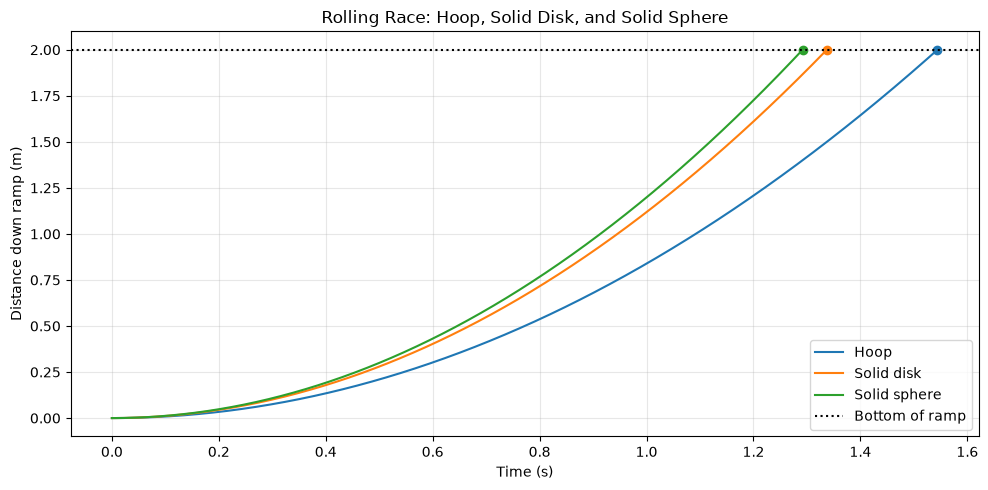

In [12]:
# Store each object's simulation results under its name.
rolling_results = {}

print(
    f"{'Object':<15} {'Simulated t (s)':>17}"
    f" {'Predicted t (s)':>17} {'Difference (s)':>17}"
)

plt.figure(figsize=(10, 5))

for name, c in rolling_shapes.items():
    times, positions, velocities, angular_velocities = simulate_rolling(
        c=c,
        beta=beta,
        ramp_length=ramp_length,
        radius=radius_rolling,
        dt=dt_rolling
    )

    rolling_results[name] = {
        "time": times,
        "position": positions,
        "velocity": velocities,
        "omega": angular_velocities
    }

    acceleration = rolling_accel(beta, c, g)
    predicted_time = np.sqrt(2 * ramp_length / acceleration)
    simulated_time = times[-1]
    difference = abs(simulated_time - predicted_time)

    print(
        f"{name:<15} {simulated_time:>17.6f}"
        f" {predicted_time:>17.6f} {difference:>17.3e}"
    )

    plt.plot(times, positions, label=name)
    plt.scatter(times[-1], positions[-1], color=plt.gca().lines[-1].get_color())

plt.axhline(
    ramp_length, color="black", linestyle=":",
    label="Bottom of ramp"
)

plt.xlabel("Time (s)")
plt.ylabel("Distance down ramp (m)")
plt.title("Rolling Race: Hoop, Solid Disk, and Solid Sphere")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Energy during rolling

I will track the solid disk's translational kinetic energy,
rotational kinetic energy, and gravitational potential energy:

$$
K_{\mathrm{trans}}=\frac{1}{2}mv^2,
$$

$$
K_{\mathrm{rot}}=\frac{1}{2}I\omega^2,
$$

$$
U=mg(s_{\mathrm{end}}-s)\sin(\beta).
$$

The potential energy will be zero at the bottom of the ramp.
For ideal rolling without slipping on a stationary ramp, static
friction does no work, so the total mechanical energy should remain
constant:

$$
E=K_{\mathrm{trans}}+K_{\mathrm{rot}}+U.
$$

Using $I=cmR^2$ and $\omega=v/R$, the rotational fraction of the
total kinetic energy is

$$
\frac{K_{\mathrm{rot}}}{K_{\mathrm{trans}}+K_{\mathrm{rot}}}
=\frac{c}{1+c}.
$$

For a solid disk, this fraction is $1/3$. I will check it at the
bottom of the ramp, where the kinetic energy is nonzero.

Initial total energy: 6.710435 J
Final total energy: 6.710435 J
Final translational kinetic energy: 4.473623 J
Final rotational kinetic energy: 2.236812 J
Maximum absolute energy deviation: 1.723e-13 J
Maximum relative energy deviation: 2.568e-14
Measured rotational fraction: 0.333333
Predicted rotational fraction: 0.333333


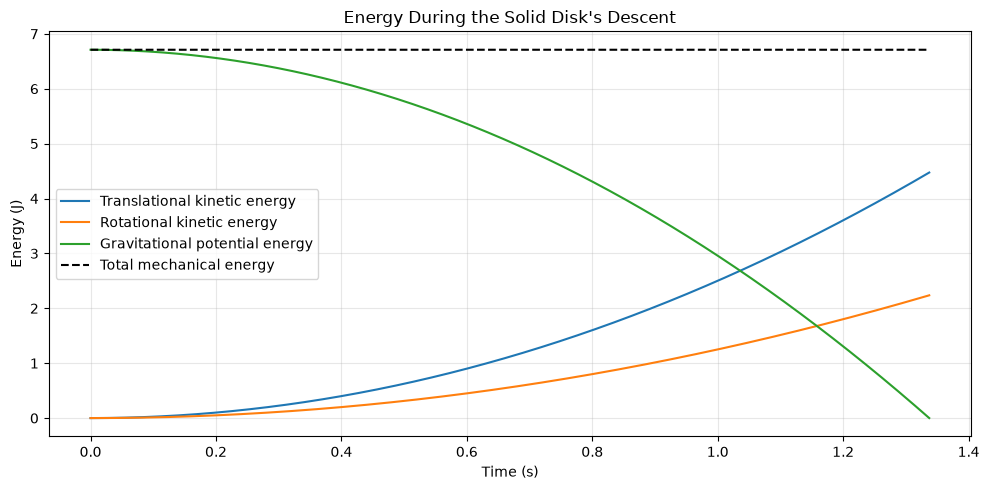

In [13]:
# Retrieve the solid disk's stored simulation results.
disk_results = rolling_results["Solid disk"]

t_disk = disk_results["time"]
s_disk = disk_results["position"]
v_disk = disk_results["velocity"]
omega_disk = disk_results["omega"]

c_disk = rolling_shapes["Solid disk"]
I_disk = c_disk * mass_rolling * radius_rolling**2

# Calculate energy at every stored time.
K_trans = 0.5 * mass_rolling * v_disk**2
K_rot = 0.5 * I_disk * omega_disk**2

height_disk = (ramp_length - s_disk) * np.sin(beta)
U_disk = mass_rolling * g * height_disk

E_disk = K_trans + K_rot + U_disk

# Check energy conservation and the rotational energy fraction.
max_energy_deviation = np.max(np.abs(E_disk - E_disk[0]))
relative_energy_deviation = max_energy_deviation / abs(E_disk[0])

rotation_fraction = K_rot[-1] / (K_trans[-1] + K_rot[-1])
predicted_fraction = c_disk / (1 + c_disk)

print(f"Initial total energy: {E_disk[0]:.6f} J")
print(f"Final total energy: {E_disk[-1]:.6f} J")
print(f"Final translational kinetic energy: {K_trans[-1]:.6f} J")
print(f"Final rotational kinetic energy: {K_rot[-1]:.6f} J")
print(f"Maximum absolute energy deviation: {max_energy_deviation:.3e} J")
print(f"Maximum relative energy deviation: {relative_energy_deviation:.3e}")
print(f"Measured rotational fraction: {rotation_fraction:.6f}")
print(f"Predicted rotational fraction: {predicted_fraction:.6f}")

plt.figure(figsize=(10, 5))

plt.plot(t_disk, K_trans, label="Translational kinetic energy")
plt.plot(t_disk, K_rot, label="Rotational kinetic energy")
plt.plot(t_disk, U_disk, label="Gravitational potential energy")
plt.plot(
    t_disk, E_disk,
    color="black", linestyle="--",
    label="Total mechanical energy"
)

plt.xlabel("Time (s)")
plt.ylabel("Energy (J)")
plt.title("Energy During the Solid Disk's Descent")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Part B interpretation

The sphere reached the bottom first, followed by the disk and then
the hoop. This matched the predicted accelerations and finishing
times. The simulated times agreed with the theoretical values to
within floating-point rounding.

For the disk, gravitational potential energy became both translational
and rotational kinetic energy. The total mechanical energy stayed
constant to within rounding error, and rotation accounted for one
third of the final kinetic energy, as predicted.

The acceleration depended on the shape coefficient, but not on mass
or radius. Those quantities canceled when the force equation, torque
equation, and rolling constraint were combined. This result assumes
ideal rolling without slipping and enough static friction to maintain
that condition.

The hoop devoted a larger fraction of its kinetic energy to rotation
than the disk or sphere. For the same vertical drop, this left it with
a smaller translational speed, explaining why it finished last.

## Part C: Spinning skater

I will model a skater pulling their arms inward while rotating about
a fixed vertical axis. I will assume that the external torque about
this axis is negligible, so angular momentum remains constant:

$$
L=I(t)\omega(t)=L_0.
$$

I will prescribe a decrease in the skater's moment of inertia and
calculate the angular velocity from

$$
\omega(t)=\frac{L_0}{I(t)}.
$$

As the moment of inertia decreases, the angular velocity should
increase. Unlike the rod in Part A, this system has a changing
moment of inertia. The appropriate torque equation is therefore

$$
\tau_{\mathrm{ext}}=\frac{d}{dt}(I\omega)
=I\frac{d\omega}{dt}+\frac{dI}{dt}\omega.
$$

Zero external torque does not require constant angular velocity
when the moment of inertia changes.

In [14]:
# Initial rotational state.
I_skater_initial = 4.0  # kg m^2
I_skater_final = 2.0    # kg m^2
omega_skater_initial = 2.0  # rad/s

# Timing of the inward arm movement.
pull_start = 2.0  # s
pull_end = 6.0    # s

duration_skater = 8.0  # s
dt_skater = 0.01       # s

# Conserved angular momentum and endpoint predictions.
L_skater_initial = I_skater_initial * omega_skater_initial
omega_skater_predicted = L_skater_initial / I_skater_final

K_skater_initial = 0.5 * I_skater_initial * omega_skater_initial**2
K_skater_predicted = 0.5 * I_skater_final * omega_skater_predicted**2

print(f"Initial moment of inertia: {I_skater_initial:.2f} kg m^2")
print(f"Final moment of inertia: {I_skater_final:.2f} kg m^2")
print(f"Conserved angular momentum: {L_skater_initial:.2f} kg m^2/s")
print(f"Initial angular velocity: {omega_skater_initial:.2f} rad/s")
print(f"Predicted final angular velocity: {omega_skater_predicted:.2f} rad/s")
print(f"Initial rotational kinetic energy: {K_skater_initial:.2f} J")
print(f"Predicted final rotational kinetic energy: {K_skater_predicted:.2f} J")

Initial moment of inertia: 4.00 kg m^2
Final moment of inertia: 2.00 kg m^2
Conserved angular momentum: 8.00 kg m^2/s
Initial angular velocity: 2.00 rad/s
Predicted final angular velocity: 4.00 rad/s
Initial rotational kinetic energy: 8.00 J
Predicted final rotational kinetic energy: 16.00 J


### Prescribing the change in moment of inertia

I will hold the moment of inertia constant for the first two seconds,
decrease it smoothly between two and six seconds, and then hold it
at its final value.

During the change, I will use a dimensionless progress variable:

$$
u=\frac{t-t_{\mathrm{start}}}{t_{\mathrm{end}}-t_{\mathrm{start}}},
$$

restricted to the interval from zero to one. The interpolation function

$$
S(u)=3u^2-2u^3
$$

goes from zero to one with zero slope at both ends. I will use it to
avoid an abrupt start or stop in the rate of change of the moment
of inertia:

$$
I(t)=I_{\mathrm{initial}}
+(I_{\mathrm{final}}-I_{\mathrm{initial}})S(u).
$$

This prescribes the arm movement rather than modeling the muscles
or individual body parts.

In [15]:
def skater_inertia(times, I_initial, I_final, start, end):
    """Prescribe a smooth transition between two moments of inertia."""
    progress = (np.asarray(times) - start) / (end - start)
    progress = np.clip(progress, 0.0, 1.0)

    smooth_progress = 3 * progress**2 - 2 * progress**3

    return I_initial + (I_final - I_initial) * smooth_progress

### Calculating and plotting the rotation

I will evaluate the prescribed moment of inertia at each stored time,
then calculate angular velocity using conservation of angular momentum:

$$
\omega(t)=\frac{L_0}{I(t)}.
$$

I will also calculate angular momentum and rotational kinetic energy:

$$
L(t)=I(t)\omega(t),
$$

$$
K_{\mathrm{rot}}(t)=\frac{1}{2}I(t)\omega(t)^2
=\frac{L_0^2}{2I(t)}.
$$

I expect angular momentum to remain constant while angular velocity
and rotational kinetic energy increase as the moment of inertia
decreases.

Because angular momentum conservation is built into the calculation,
a constant angular momentum plot will check that the code implements
this relationship consistently. It will not independently demonstrate
that a numerical integrator conserves angular momentum.

Final moment of inertia: 2.00 kg m^2
Final angular velocity: 4.00 rad/s
Initial angular momentum: 8.00 kg m^2/s
Final angular momentum: 8.00 kg m^2/s
Maximum angular momentum deviation: 8.882e-16 kg m^2/s
Initial rotational kinetic energy: 8.00 J
Final rotational kinetic energy: 16.00 J
Increase in rotational kinetic energy: 8.00 J


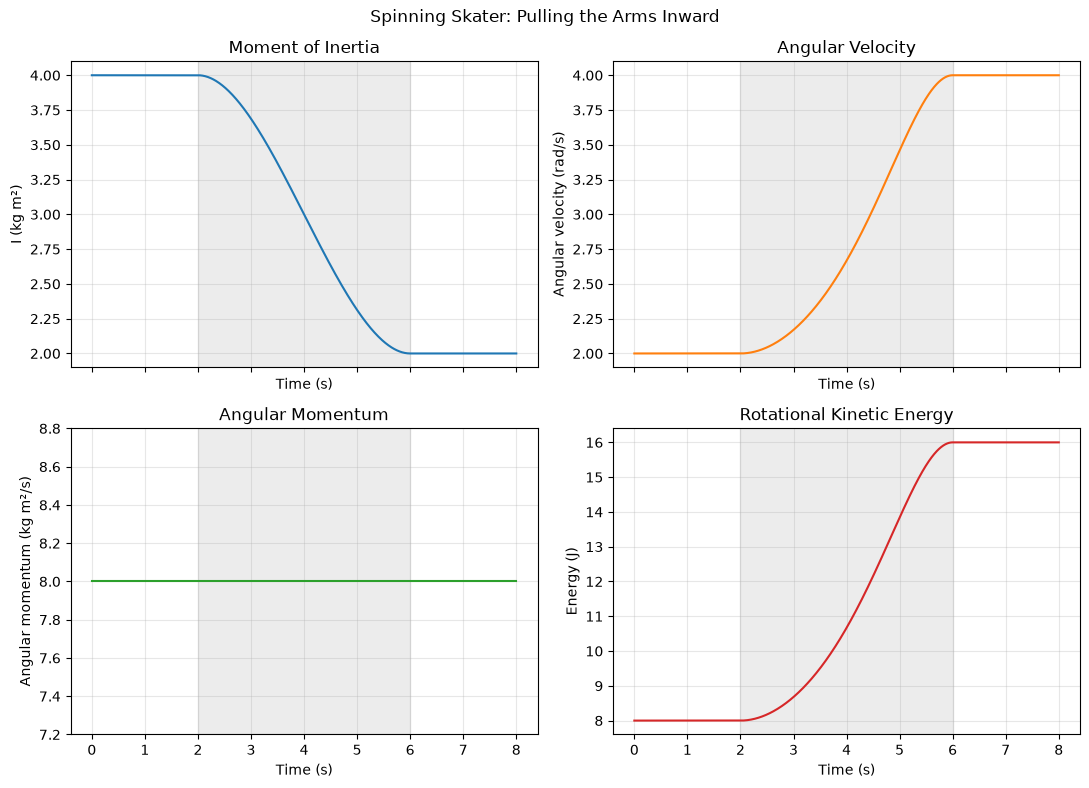

In [16]:
# Create equally spaced times, including the initial and final times.
n_steps_skater = int(round(duration_skater / dt_skater))
t_skater = np.linspace(0.0, duration_skater, n_steps_skater + 1)

# Evaluate the prescribed moment of inertia.
I_skater = skater_inertia(
    times=t_skater,
    I_initial=I_skater_initial,
    I_final=I_skater_final,
    start=pull_start,
    end=pull_end
)

# Calculate rotation from constant angular momentum.
omega_skater = L_skater_initial / I_skater
L_skater = I_skater * omega_skater
K_skater = 0.5 * I_skater * omega_skater**2

max_L_deviation = np.max(np.abs(L_skater - L_skater_initial))

print(f"Final moment of inertia: {I_skater[-1]:.2f} kg m^2")
print(f"Final angular velocity: {omega_skater[-1]:.2f} rad/s")
print(f"Initial angular momentum: {L_skater[0]:.2f} kg m^2/s")
print(f"Final angular momentum: {L_skater[-1]:.2f} kg m^2/s")
print(f"Maximum angular momentum deviation: {max_L_deviation:.3e} kg m^2/s")
print(f"Initial rotational kinetic energy: {K_skater[0]:.2f} J")
print(f"Final rotational kinetic energy: {K_skater[-1]:.2f} J")
print(f"Increase in rotational kinetic energy: "
      f"{K_skater[-1] - K_skater[0]:.2f} J")

# Plot all four quantities over the same time interval.
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)

axes[0, 0].plot(t_skater, I_skater, color="tab:blue")
axes[0, 0].set_title("Moment of Inertia")
axes[0, 0].set_ylabel("I (kg m²)")

axes[0, 1].plot(t_skater, omega_skater, color="tab:orange")
axes[0, 1].set_title("Angular Velocity")
axes[0, 1].set_ylabel("Angular velocity (rad/s)")

axes[1, 0].plot(t_skater, L_skater, color="tab:green")
axes[1, 0].set_title("Angular Momentum")
axes[1, 0].set_ylabel("Angular momentum (kg m²/s)")
axes[1, 0].set_ylim(0.9 * L_skater_initial, 1.1 * L_skater_initial)

axes[1, 1].plot(t_skater, K_skater, color="tab:red")
axes[1, 1].set_title("Rotational Kinetic Energy")
axes[1, 1].set_ylabel("Energy (J)")

for ax in axes.flat:
    ax.axvspan(
        pull_start, pull_end,
        color="gray", alpha=0.15
    )
    ax.set_xlabel("Time (s)")
    ax.grid(True, alpha=0.3)

fig.suptitle("Spinning Skater: Pulling the Arms Inward")
plt.tight_layout()
plt.show()

### Checking the endpoint predictions

For constant angular momentum, the angular velocity and rotational
kinetic energy are both inversely proportional to the moment of inertia:

$$
\frac{\omega_f}{\omega_i}=\frac{I_i}{I_f},
$$

$$
\frac{K_f}{K_i}=\frac{I_i}{I_f}.
$$

Halving the moment of inertia should therefore double both quantities.
I will check these ratios and calculate the increase in rotational
kinetic energy.

These are consistency checks on the prescribed model. The calculation
uses angular momentum conservation directly rather than integrating
an equation of motion.

In [17]:
# Compare the calculated endpoint ratios with the prediction.
predicted_ratio = I_skater_initial / I_skater_final

omega_ratio = omega_skater[-1] / omega_skater[0]
energy_ratio = K_skater[-1] / K_skater[0]

# Net work transferred into the modeled rotational motion.
work_into_rotation = K_skater[-1] - K_skater[0]

print(f"Predicted ratio: {predicted_ratio:.6f}")
print(f"Final / initial angular velocity: {omega_ratio:.6f}")
print(f"Final / initial rotational energy: {energy_ratio:.6f}")

print(
    "Angular velocity ratio agrees:",
    np.isclose(omega_ratio, predicted_ratio)
)
print(
    "Rotational energy ratio agrees:",
    np.isclose(energy_ratio, predicted_ratio)
)

print(f"Net work added to rotational motion: {work_into_rotation:.6f} J")

Predicted ratio: 2.000000
Final / initial angular velocity: 2.000000
Final / initial rotational energy: 2.000000
Angular velocity ratio agrees: True
Rotational energy ratio agrees: True
Net work added to rotational motion: 8.000000 J


### Part C interpretation and conservation diagnostics

As the skater's moment of inertia decreased from 4 to 2 kg m²,
their angular velocity increased from 2 to 4 rad/s. Angular momentum
remained constant to within floating-point rounding, consistent with
the torque-free assumption built into the model.

Rotational kinetic energy increased from 8 to 16 J. This did not
violate energy conservation: the skater did work while pulling their
arms inward, transferring internal energy into rotational motion.
The rotational kinetic energy alone was not conserved. The model
prescribed the change in moment of inertia without tracking the
skater's internal energy or detailed arm motion.

Different conservation checks can reveal different problems in a
simulation, but each check requires the appropriate physical conditions:

- **Energy:** In a system where mechanical energy should be conserved,
  unexpected drift can indicate an unsuitable time step, an integration
  error, or an incorrect force or potential-energy formula. For example,
  a sign error in gravitational potential energy could spoil the rolling
  disk's energy check. Mechanical energy need not remain constant when
  friction dissipates energy or internal work adds energy to the motion.

- **Linear momentum:** Total linear momentum should remain constant
  when the net external force is zero. In a collision simulation,
  unequal and opposite internal impulses could produce an incorrect
  change in total momentum. Momentum need not be conserved for the
  rolling object alone because gravity and the ramp exert external forces.

- **Angular momentum:** Angular momentum about a fixed inertial origin
  should remain constant when the net external torque about that origin
  is zero. Accidentally holding the skater's angular velocity constant
  while decreasing their moment of inertia would violate this condition.
  For the physical pendulum, angular momentum about the pivot was not
  conserved because gravity exerted a torque.

These checks are most useful when combined with theoretical predictions
and time-step refinement. Passing one check does not guarantee that
every part of a simulation is correct.

## Bonus: A rolling disk collides with a block

I will model the solid disk reaching a horizontal surface and colliding
with a stationary block. I will assume that the transition from the
ramp to the horizontal surface preserves the disk's speed and spin.

The collision will be one-dimensional, with the contact force acting
through the disk's center. I will neglect frictional impulses during
the short collision. Under these assumptions, the collision changes
the translational velocities but produces no angular impulse about
the disk's center.

I will reuse the collision relationships from Lab 4:

$$
m_1u_1+m_2u_2=m_1v_1+m_2v_2,
$$

$$
v_2-v_1=e(u_1-u_2),
$$

where $u$ denotes velocity before impact, $v$ denotes velocity after
impact, and $e$ is the coefficient of restitution.

The disk's angular velocity will remain unchanged during impact.
I will check both translational and rotational kinetic energy.

In [18]:
def collide_1d(m1, m2, u1, u2, e):
    """Return final velocities for a one-dimensional collision."""
    v1 = (
        (m1 - e * m2) * u1 + (1 + e) * m2 * u2
    ) / (m1 + m2)

    v2 = (
        (1 + e) * m1 * u1 + (m2 - e * m1) * u2
    ) / (m1 + m2)

    return v1, v2

### Initial conditions and collision calculation

I will use the disk's final speed and angular velocity from Part B
as its values immediately before impact. The stationary block will
have a mass of 2 kg, and the coefficient of restitution will be 0.8.

I will calculate the final translational velocities using the collision
function and retain the disk's initial spin. I will then check whether
the disk still satisfies the rolling condition immediately afterward.

For the spin convention used here, pure rolling to the right requires

$$
v=R\omega.
$$

A nonzero value of $v-R\omega$ indicates slipping at the bottom contact
point. I will not impose the rolling condition again without modeling
the friction needed to restore it.

In [19]:
# Use the disk's state at the bottom of the ramp.
m_disk_collision = mass_rolling
m_block = 2.0  # kg
e_collision = 0.8

u_disk = v_disk[-1]
u_block = 0.0
omega_before = omega_disk[-1]

v_disk_after, v_block_after = collide_1d(
    m1=m_disk_collision,
    m2=m_block,
    u1=u_disk,
    u2=u_block,
    e=e_collision
)

# No angular impulse about the disk's center in this model.
omega_after = omega_before

slip_speed_after = v_disk_after - radius_rolling * omega_after

print(f"Coefficient of restitution: {e_collision:.2f}")
print(f"Disk velocity before impact: {u_disk:.6f} m/s")
print(f"Disk velocity after impact: {v_disk_after:.6f} m/s")
print(f"Block velocity after impact: {v_block_after:.6f} m/s")
print(f"Disk angular velocity before impact: {omega_before:.6f} rad/s")
print(f"Disk angular velocity after impact: {omega_after:.6f} rad/s")
print(f"Contact-point slip velocity after impact: {slip_speed_after:.6f} m/s")
print(
    "Pure rolling immediately after impact:",
    np.isclose(slip_speed_after, 0.0)
)

Coefficient of restitution: 0.80
Disk velocity before impact: 2.991195 m/s
Disk velocity after impact: -0.598239 m/s
Block velocity after impact: 1.794717 m/s
Disk angular velocity before impact: 29.911949 rad/s
Disk angular velocity after impact: 29.911949 rad/s
Contact-point slip velocity after impact: -3.589434 m/s
Pure rolling immediately after impact: False


### Momentum and energy checks

I will compare the total horizontal momentum before and after impact.
Under the assumption of negligible external horizontal impulse,
it should be conserved.

The kinetic energy will include the translational energy of both
objects and the rotational energy of the disk:

$$
K=\frac12m_1v_1^2+\frac12m_2v_2^2+\frac12I\omega^2.
$$

For this collision model, the predicted kinetic energy loss is

$$
K_{\mathrm{before}}-K_{\mathrm{after}}
=\frac12\mu(1-e^2)(u_1-u_2)^2,
$$

where $\mu=m_1m_2/(m_1+m_2)$ is the reduced mass.

The rotational contribution will not change during the collision.
I will also check an elastic collision with $e=1$, which should
conserve total kinetic energy under these assumptions.

In [20]:
# Horizontal momentum.
p_before = m_disk_collision * u_disk + m_block * u_block
p_after = m_disk_collision * v_disk_after + m_block * v_block_after

# Separate the kinetic energy contributions.
K_disk_trans_before = 0.5 * m_disk_collision * u_disk**2
K_block_before = 0.5 * m_block * u_block**2
K_spin_before = 0.5 * I_disk * omega_before**2

K_disk_trans_after = 0.5 * m_disk_collision * v_disk_after**2
K_block_after = 0.5 * m_block * v_block_after**2
K_spin_after = 0.5 * I_disk * omega_after**2

K_total_before = K_disk_trans_before + K_block_before + K_spin_before
K_total_after = K_disk_trans_after + K_block_after + K_spin_after

energy_loss = K_total_before - K_total_after

reduced_mass = (
    m_disk_collision * m_block / (m_disk_collision + m_block)
)
predicted_loss = (
    0.5 * reduced_mass * (1 - e_collision**2) * (u_disk - u_block)**2
)

# Recover restitution from the calculated velocities.
measured_e = (v_block_after - v_disk_after) / (u_disk - u_block)

# Elastic limiting-case check.
v_disk_elastic, v_block_elastic = collide_1d(
    m_disk_collision, m_block, u_disk, u_block, e=1.0
)

K_total_elastic = (
    0.5 * m_disk_collision * v_disk_elastic**2
    + 0.5 * m_block * v_block_elastic**2
    + K_spin_before
)

print(f"Momentum before impact: {p_before:.6f} kg m/s")
print(f"Momentum after impact: {p_after:.6f} kg m/s")
print(f"Momentum conserved: {np.isclose(p_before, p_after)}")

print(f"\nTotal kinetic energy before: {K_total_before:.6f} J")
print(f"Total kinetic energy after: {K_total_after:.6f} J")
print(f"Calculated energy loss: {energy_loss:.6f} J")
print(f"Predicted energy loss: {predicted_loss:.6f} J")
print(f"Energy loss agrees: {np.isclose(energy_loss, predicted_loss)}")

print(f"\nRecovered restitution coefficient: {measured_e:.6f}")
print(f"Disk rotational energy before: {K_spin_before:.6f} J")
print(f"Disk rotational energy after: {K_spin_after:.6f} J")
print(
    "Elastic case conserves kinetic energy:",
    np.isclose(K_total_elastic, K_total_before)
)

Momentum before impact: 2.991195 kg m/s
Momentum after impact: 2.991195 kg m/s
Momentum conserved: True

Total kinetic energy before: 6.710435 J
Total kinetic energy after: 5.636766 J
Calculated energy loss: 1.073670 J
Predicted energy loss: 1.073670 J
Energy loss agrees: True

Recovered restitution coefficient: 0.800000
Disk rotational energy before: 2.236812 J
Disk rotational energy after: 2.236812 J
Elastic case conserves kinetic energy: True


### Comparing the energy contributions

I will plot the kinetic energy before and immediately after impact,
separating the disk's translation, the block's translation, and the
disk's rotation.

The block should gain translational kinetic energy, while the disk
should lose translational kinetic energy. The disk's rotational
energy should remain unchanged under the central, frictionless
impact assumption.

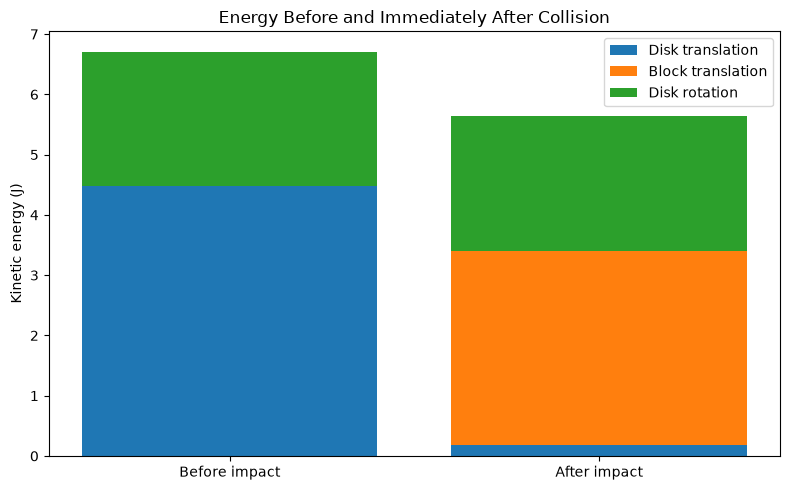

In [21]:
labels = ["Before impact", "After impact"]

disk_translation = np.array([
    K_disk_trans_before, K_disk_trans_after
])
block_translation = np.array([
    K_block_before, K_block_after
])
disk_rotation = np.array([
    K_spin_before, K_spin_after
])

plt.figure(figsize=(8, 5))

plt.bar(labels, disk_translation, label="Disk translation")
plt.bar(
    labels, block_translation,
    bottom=disk_translation,
    label="Block translation"
)
plt.bar(
    labels, disk_rotation,
    bottom=disk_translation + block_translation,
    label="Disk rotation"
)

plt.ylabel("Kinetic energy (J)")
plt.title("Energy Before and Immediately After Collision")
plt.legend()
plt.tight_layout()
plt.show()

### Bonus interpretation

The collision conserved horizontal momentum, while total kinetic
energy decreased for a coefficient of restitution of 0.8. The energy
loss agreed with the theoretical prediction. Setting the coefficient
to 1 recovered conservation of kinetic energy.

The disk rebounded and transferred translational kinetic energy to
the block. Its rotational kinetic energy remained unchanged because
the assumed collision force acted through its center and produced
no torque about that center.

Immediately after impact, the disk no longer satisfied the rolling
condition. Its translational velocity changed while its angular
velocity did not. On a rough surface, subsequent sliding friction
would change both its translation and rotation and dissipate
mechanical energy. That later motion was not included here.

A collision with a tangential frictional impulse or an off-center
force could also change the spin during impact. Modeling that would
require an angular impulse calculation in addition to the
one-dimensional collision formulas.